# Exploration initiale — DVF géolocalisé (2021-2025)

Objectif : comprendre la structure du fichier avant nettoyage (Phase 2 - Talend).

Fichier : `data/raw/dvf.csv` — ~3.5 Go, ~20.4 millions de lignes.

On lit par **chunks** (morceaux) pour ne pas saturer la RAM.

In [1]:
import pandas as pd

CSV_PATH = r"C:\Users\eree\Documents\projet-immo-france\data\raw\dvf.csv"
CHUNK_SIZE = 500_000  # nombre de lignes lues à la fois

import os

# Dossier de cache pour les résultats intermédiaires coûteux à recalculer (keep_mask, résumés par transaction).
# Évite de dépendre de variables encore en mémoire du kernel : les cellules qui en ont besoin plus loin
# rechargent depuis le disque si elles ne trouvent pas la variable déjà calculée dans la session en cours.
PROCESSED_DIR = os.path.join(os.path.dirname(os.path.dirname(CSV_PATH)), "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)
KEEP_MASK_PATH = os.path.join(PROCESSED_DIR, "keep_mask.npy")
FINAL_RESUME_DEDUP_PATH = os.path.join(PROCESSED_DIR, "final_resume_dedup.parquet")

In [2]:
# Th\u00e8me graphique commun \u2014 palette bleu / rouge (immo France)
# Bleu : situation normale, donn\u00e9e conserv\u00e9e, volum\u00e9trie g\u00e9n\u00e9rale (grad\u00e9 clair -> marine selon l'importance)
# Rouge : anomalie, exclusion, seuil d\u00e9pass\u00e9 (grad\u00e9 clair -> fonc\u00e9 selon la gravit\u00e9)
COLORS = {
    "bleu_clair": "#dbeafe",
    "bleu_secondaire": "#60a5fa",
    "bleu_primaire": "#2563eb",
    "bleu_marine": "#1e3a8a",
    "rouge_leger": "#fecaca",
    "rouge_modere": "#f87171",
    "rouge_exclusion": "#dc2626",
    "rouge_critique": "#7f1d1d",
}

import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})


## 1. Aperçu rapide (juste les premières lignes)

In [3]:
df_sample = pd.read_csv(CSV_PATH, nrows=1000)
df_sample.head(10)

,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,...,type_local,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude
0,2021-1,2021-01-05,1,Vente,185000.0,5080.0,NaN,CHE DE VOGELAS,0471,1370,...,Dépendance,NaN,0.0,S,sols,NaN,NaN,2410.0,5.386107,46.327101
1,2021-1,2021-01-05,1,Vente,185000.0,5080.0,NaN,CHE DE VOGELAS,0471,1370,...,Maison,97.0,5.0,S,sols,NaN,NaN,2410.0,5.386107,46.327101
2,2021-2,2021-01-06,1,Vente,10.0,NaN,NaN,ROUGEMONT,B043,1290,...,NaN,NaN,NaN,BT,taillis simples,NaN,NaN,530.0,4.844318,46.224242
3,2021-3,2021-01-04,1,Vente,204332.0,7.0,NaN,ALL DES ECUREUILS,0276,1310,...,Maison,88.0,4.0,S,sols,NaN,NaN,866.0,5.157674,46.201035
4,2021-4,2021-01-06,1,Vente,320000.0,87.0,NaN,RTE DE CERTINES,0140,1250,...,Dépendance,NaN,0.0,S,sols,NaN,NaN,1426.0,5.273214,46.156320
5,2021-4,2021-01-06,1,Vente,320000.0,87.0,NaN,RTE DE CERTINES,0140,1250,...,Maison,168.0,5.0,S,sols,NaN,NaN,1426.0,5.273214,46.156320
6,2021-5,2021-01-04,2,Vente,36.3,NaN,NaN,COMBET MAILLET,B077,1250,...,NaN,NaN,NaN,BT,taillis simples,NaN,NaN,121.0,5.462968,46.256257
7,2021-6,2021-01-04,1,Vente,176000.0,210.0,NaN,RUE GEORGE SAND,0820,1000,...,Appartement,71.0,3.0,NaN,NaN,NaN,NaN,NaN,5.200093,46.210276
8,2021-6,2021-01-04,1,Vente,176000.0,210.0,NaN,RUE GEORGE SAND,0820,1000,...,Dépendance,NaN,0.0,NaN,NaN,NaN,NaN,NaN,5.200093,46.210276
9,2021-7,2021-01-11,2,Vente,400.0,NaN,NaN,PRE BROUILLET,B085,1310,...,NaN,NaN,NaN,P,prés,NaN,NaN,460.0,5.115375,46.211715


In [4]:
df_sample.dtypes

id_mutation                      object
date_mutation                    object
numero_disposition                int64
nature_mutation                  object
valeur_fonciere                 float64
adresse_numero                  float64
adresse_suffixe                  object
adresse_nom_voie                 object
adresse_code_voie                object
code_postal                       int64
code_commune                      int64
nom_commune                      object
code_departement                  int64
ancien_code_commune             float64
ancien_nom_commune              float64
id_parcelle                      object
ancien_id_parcelle              float64
numero_volume                   float64
lot1_numero                     float64
lot1_surface_carrez             float64
lot2_numero                     float64
lot2_surface_carrez             float64
lot3_numero                     float64
lot3_surface_carrez             float64
lot4_numero                     float64


## 2. Nombre total de lignes (comptage rapide sans tout charger)

In [5]:
total_rows = 0
for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False):
    total_rows += len(chunk)

print(f"Nombre total de lignes : {total_rows:,}")

Nombre total de lignes : 20,382,915


20 382 915 lignes au total sur la période

## 3. Valeurs manquantes par colonne (calcul cumulé sur tous les chunks)

In [6]:
missing_counts = None
total_rows_check = 0

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False):
    chunk_missing = chunk.isna().sum()
    missing_counts = chunk_missing if missing_counts is None else missing_counts + chunk_missing
    total_rows_check += len(chunk)

missing_pct = (missing_counts / total_rows_check * 100).round(2)
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)

missing_summary

,missing_count,missing_pct
ancien_code_commune,20382272,100.00
ancien_id_parcelle,20382899,100.00
ancien_nom_commune,20382272,100.00
lot5_surface_carrez,20377055,99.97
lot4_surface_carrez,20366397,99.92
numero_volume,20336924,99.77
lot5_numero,20333459,99.76
lot3_surface_carrez,20315867,99.67
lot4_numero,20270998,99.45
lot3_numero,20036784,98.30


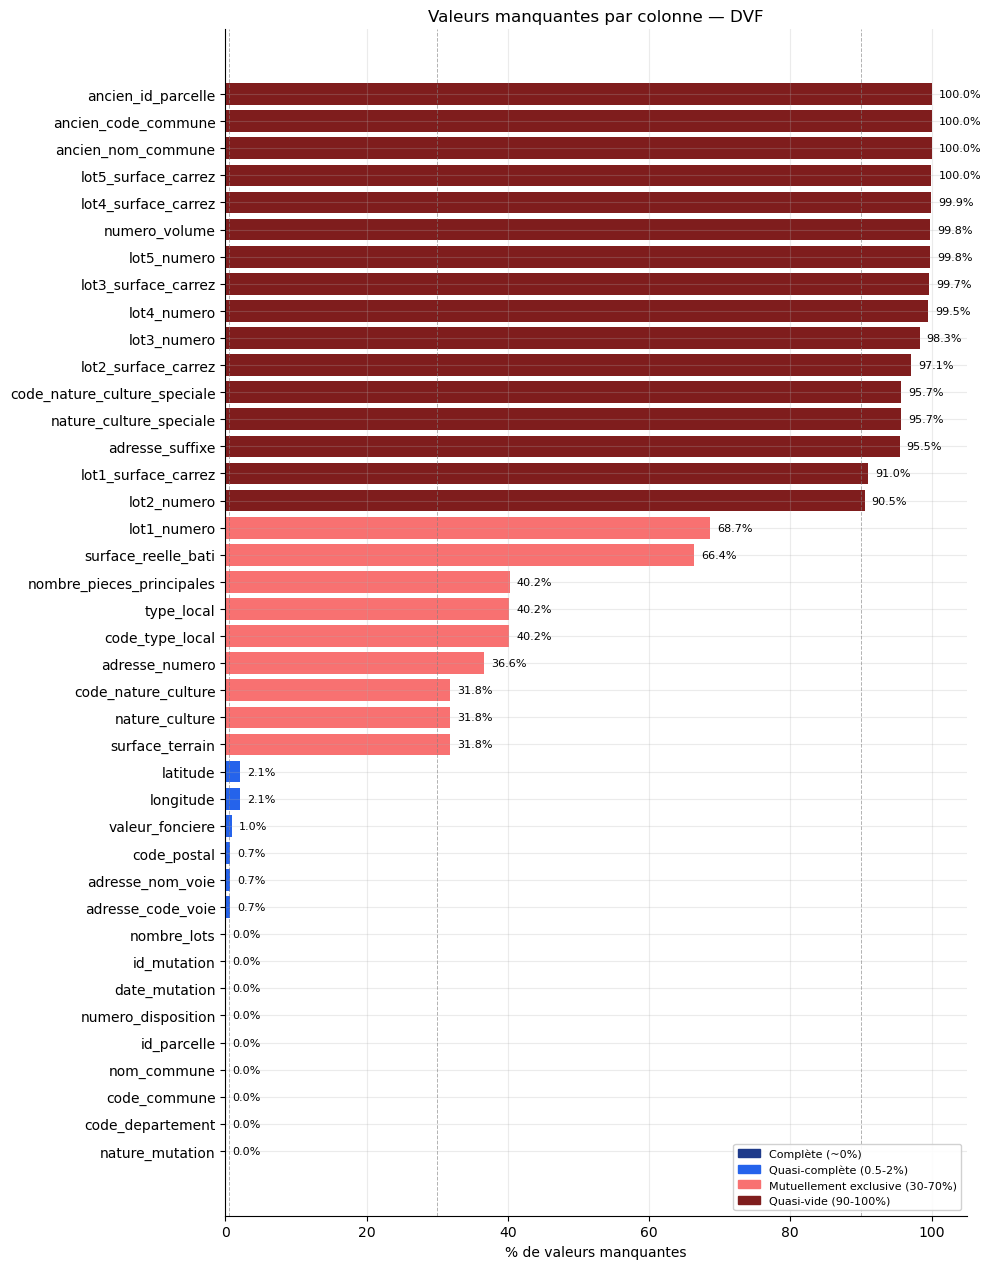

In [7]:
import matplotlib.pyplot as plt

def _bucket_color(pct):
    if pct >= 90:
        return COLORS["rouge_critique"]   # quasi-vide
    elif pct >= 30:
        return COLORS["rouge_modere"]     # mutuellement exclusif selon le bien
    elif pct >= 0.5:
        return COLORS["bleu_primaire"]    # quasi-complet
    else:
        return COLORS["bleu_marine"]      # complet

plot_data = missing_summary.sort_values("missing_pct", ascending=True)
colors = [_bucket_color(p) for p in plot_data["missing_pct"]]

fig, ax = plt.subplots(figsize=(10, max(6, len(plot_data) * 0.32)))
ax.barh(plot_data.index, plot_data["missing_pct"], color=colors)

for y, pct in enumerate(plot_data["missing_pct"]):
    ax.text(pct + 1, y, f"{pct:.1f}%", va="center", fontsize=8)

for x in (0.5, 30, 90):
    ax.axvline(x, color="grey", linestyle="--", linewidth=0.7, alpha=0.6)

ax.set_xlim(0, 105)
ax.set_xlabel("% de valeurs manquantes")
ax.set_title("Valeurs manquantes par colonne \u2014 DVF")

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=COLORS["bleu_marine"], label="Compl\u00e8te (~0%)"),
    plt.Rectangle((0, 0), 1, 1, color=COLORS["bleu_primaire"], label="Quasi-compl\u00e8te (0.5-2%)"),
    plt.Rectangle((0, 0), 1, 1, color=COLORS["rouge_modere"], label="Mutuellement exclusive (30-70%)"),
    plt.Rectangle((0, 0), 1, 1, color=COLORS["rouge_critique"], label="Quasi-vide (90-100%)"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.show()


**Structurellement quasi-vides (ignorées)** : lots 2 à 5, ancien_code/nom_commune,
numero_volume, nature_culture_speciale, adresse_suffixe (90-100% manquants).
Concernent des cas très rares (copropriétés multi-lots, fusions de communes, cultures
spéciales) — pas de traitement nécessaire, colonnes non utilisées dans le modèle.

**Mutuellement exclusives selon le type de bien (30-70% manquants)** :
surface_reelle_bati, nombre_pieces_principales, type_local, surface_terrain,
nature_culture, adresse_numero. Ces colonnes ne sont pas "sales" — elles reflètent
la nature du bien (un terrain nu n'a pas de surface bâtie, un logement n'a pas de
surface_terrain). **Décision** : filtrer sur type_local renseigné (Maison/Appartement)
pour exclure les terrains, en documentant explicitement ce choix de périmètre.

**Quasi-complètes (0.5-2%)** : longitude/latitude, valeur_fonciere, adresse_nom_voie,
code_postal. Bon niveau de fiabilité — lignes avec valeur manquante à exclure
directement (peu de perte de volume).

**Complètes (0%)** : nature_mutation, id_mutation, date_mutation, id_parcelle,
nom_commune, code_commune, code_departement. Colonnes administratives obligatoires.

## 4. Répartition de `nature_mutation`

Important : DVF contient d'autres types de mutations que les ventes classiques (donations, échanges, expropriations...). On voudra probablement filtrer sur `Vente` pour le projet prix.

In [8]:
nature_counts = None

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False, usecols=["nature_mutation"]):
    counts = chunk["nature_mutation"].value_counts()
    nature_counts = counts if nature_counts is None else nature_counts.add(counts, fill_value=0)

nature_counts.sort_values(ascending=False)

nature_mutation
Vente                                 18982926.0
Vente en l'état futur d'achèvement     1046189.0
Echange                                 237573.0
Vente terrain à bâtir                    54555.0
Adjudication                             51289.0
Expropriation                            10383.0
Name: count, dtype: float64

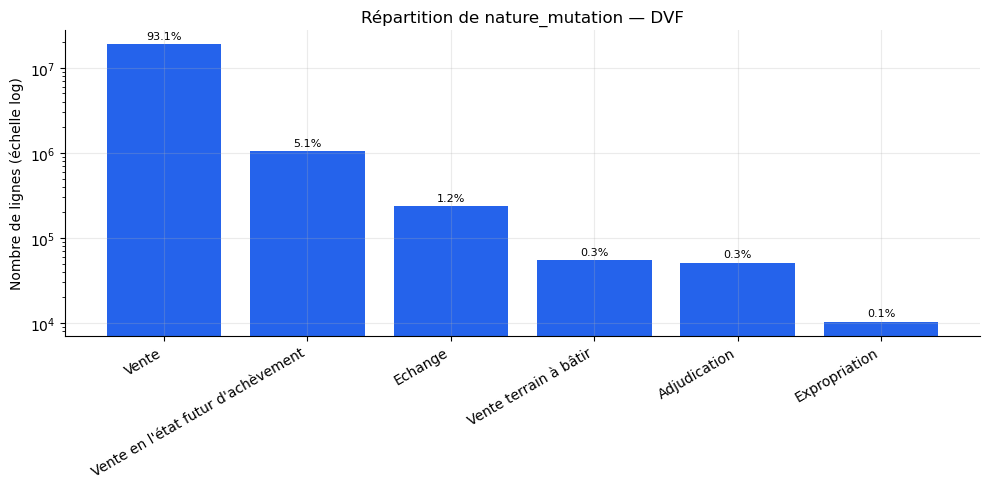

In [9]:
import matplotlib.pyplot as plt

nc = nature_counts.sort_values(ascending=False)
total_nc = nc.sum()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(nc.index.astype(str), nc.values, color=COLORS["bleu_primaire"])
ax.set_yscale("log")
ax.set_ylabel("Nombre de lignes (\u00e9chelle log)")
ax.set_title("R\u00e9partition de nature_mutation \u2014 DVF")
plt.xticks(rotation=30, ha="right")

for bar, val in zip(bars, nc.values):
    pct = val / total_nc * 100
    ax.text(bar.get_x() + bar.get_width() / 2, val * 1.15, f"{pct:.1f}%",
            ha="center", fontsize=8)

plt.tight_layout()
plt.show()


- 93% des lignes sont des "Vente" classiques
- VEFA (vente en l'état futur d'achèvement) : ~1M lignes, à décider si on l'inclut
- Echange, Adjudication, Expropriation : hors périmètre (pas de prix de marché)
- **Décision** : filtrer sur `nature_mutation == 'Vente'` pour le cœur de l'analyse

## 5. Répartition de `type_local`

In [10]:
type_local_counts = None

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False, usecols=["type_local"]):
    counts = chunk["type_local"].value_counts(dropna=False)
    type_local_counts = counts if type_local_counts is None else type_local_counts.add(counts, fill_value=0)

type_local_counts.sort_values(ascending=False)

type_local
NaN                                         8189148
Dépendance                                  5308320
Maison                                      3355671
Appartement                                 2879521
Local industriel. commercial ou assimilé     650255
Name: count, dtype: int64

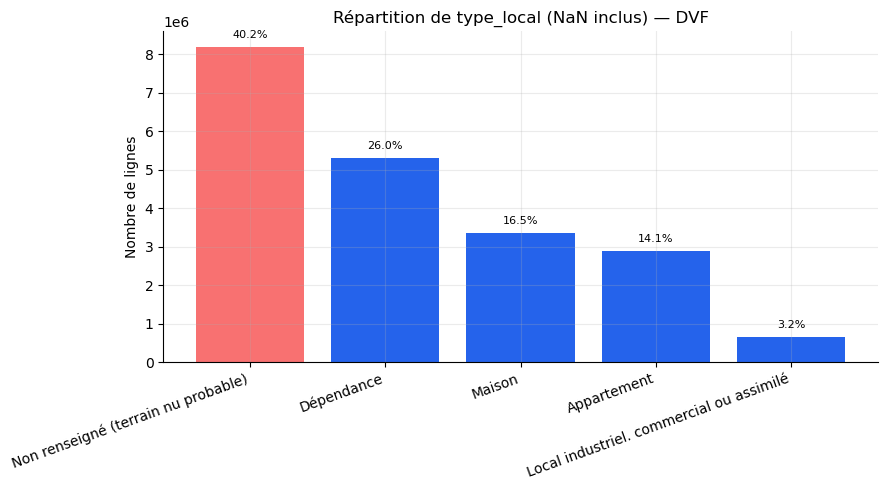

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

tl = type_local_counts.sort_values(ascending=False)
labels = ["Non renseign\u00e9 (terrain nu probable)" if pd.isna(v) else str(v) for v in tl.index]
total_tl = tl.sum()

colors = [COLORS["rouge_modere"] if lbl.startswith("Non renseign") else COLORS["bleu_primaire"] for lbl in labels]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, tl.values, color=colors)
ax.set_ylabel("Nombre de lignes")
ax.set_title("R\u00e9partition de type_local (NaN inclus) \u2014 DVF")
plt.xticks(rotation=20, ha="right")

for bar, val in zip(bars, tl.values):
    pct = val / total_tl * 100
    ax.text(bar.get_x() + bar.get_width() / 2, val + total_tl * 0.012, f"{pct:.1f}%",
            ha="center", fontsize=8)

plt.tight_layout()
plt.show()


### Répartition de type_local

- NaN (40.2%) : très probablement des terrains nus (cohérent avec surface_reelle_bati
  manquante à 66%)
- Dépendance (26.0%) : catégorie la plus fréquente en volume, mais souvent une ligne
  annexe d'une transaction Maison/Appartement (vu dès le premier aperçu : id_mutation
  2021-1 = 1 ligne Dépendance + 1 ligne Maison)
- Maison (16.5%) et Appartement (14.1%) : cœur du périmètre "logement résidentiel"
- Local industriel/commercial (3.2%) : hors périmètre pour l'analyse prix résidentiel

**Décision périmètre** : filtrer sur type_local IN ('Maison', 'Appartement') pour le
modèle de prédiction de prix résidentiel. Les lignes "Dépendance" associées à ces
transactions (même id_mutation) seront à gérer séparément — agrégation ou exclusion,
à trancher en Phase 2.

In [12]:
nombre_lots_counts = None

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False, usecols=["nombre_lots"]):
    counts = chunk["nombre_lots"].value_counts(dropna=False)
    nombre_lots_counts = counts if nombre_lots_counts is None else nombre_lots_counts.add(counts, fill_value=0)

nombre_lots_counts.sort_index()

nombre_lots
0      13993195.0
1       4456901.0
2       1586688.0
3        234214.0
4         62461.0
          ...    
161           2.0
175           1.0
188           1.0
190           1.0
236           1.0
Name: count, Length: 123, dtype: float64

68,6% des lignes ont nombre_lots = 0 \u2014 ce sont tr\u00e8s probablement les ventes sans copropri\u00e9t\u00e9 (maisons individuelles, terrains). Seulement ~10% des lignes ont 2 lots ou plus : la gestion multi-lots ne concerne qu'une minorit\u00e9 de cas. Pour la Phase 2, une r\u00e8gle simple (d\u00e9dupliquer/agr\u00e9ger par id_mutation) suffit sans sur-ing\u00e9nierer un cas qui touche peu de lignes.

In [13]:
nature_culture_counts = None
for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False, usecols=["nature_culture"]):
    counts = chunk["nature_culture"].value_counts(dropna=False)
    nature_culture_counts = counts if nature_culture_counts is None else nature_culture_counts.add(counts, fill_value=0)

nature_culture_counts.sort_values(ascending=False)

nature_culture
sols                   6944918.0
NaN                    6483813.0
terres                 1948571.0
prés                   1049676.0
jardins                 704033.0
taillis simples         593708.0
terrains a bâtir        561066.0
terrains d'agrément     551777.0
landes                  531207.0
vignes                  213915.0
futaies résineuses      193759.0
vergers                 152452.0
taillis sous futaie     101323.0
pâtures                  94153.0
bois                     70642.0
eaux                     53371.0
peupleraies              47516.0
futaies feuillues        29709.0
prés plantes             14931.0
pacages                  10520.0
futaies mixtes            8664.0
herbages                  8138.0
chemin de fer             7409.0
carrières                 3996.0
landes boisées            1932.0
prés d'embouche            711.0
terres plantées            674.0
oseraies                   331.0
Name: count, dtype: float64

**nature_culture** : largement complémentaire de type_local — sols (33.8%) et terres/
prés/jardins/landes (catégories agricoles/nature, ~30% cumulé) correspondent aux
terrains ; NaN (31.6%) correspond aux logements bâtis. Confirme que le filtre
type_local IN ('Maison', 'Appartement') isole proprement le résidentiel sans besoin
de croiser avec nature_culture pour ce périmètre.

## 6. Distribution rapide de `valeur_fonciere` (sur ventes uniquement)



In [14]:
valeurs = []

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False,
                          usecols=["nature_mutation", "valeur_fonciere"]):
    ventes = chunk[chunk["nature_mutation"] == "Vente"]["valeur_fonciere"].dropna()
    valeurs.append(ventes)

valeur_fonciere_ventes = pd.concat(valeurs)
print(f"Nombre de ventes avec valeur_fonciere renseignée : {len(valeur_fonciere_ventes):,}")
valeur_fonciere_ventes.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

Nombre de ventes avec valeur_fonciere renseignée : 18,804,329


count    1.880433e+07
mean     1.450483e+06
std      1.690477e+07
min      1.000000e-01
1%       1.000000e+02
5%       3.000000e+03
25%      6.730240e+04
50%      1.600000e+05
75%      3.000000e+05
95%      1.158230e+06
99%      1.365000e+07
max      1.415000e+10
Name: valeur_fonciere, dtype: float64

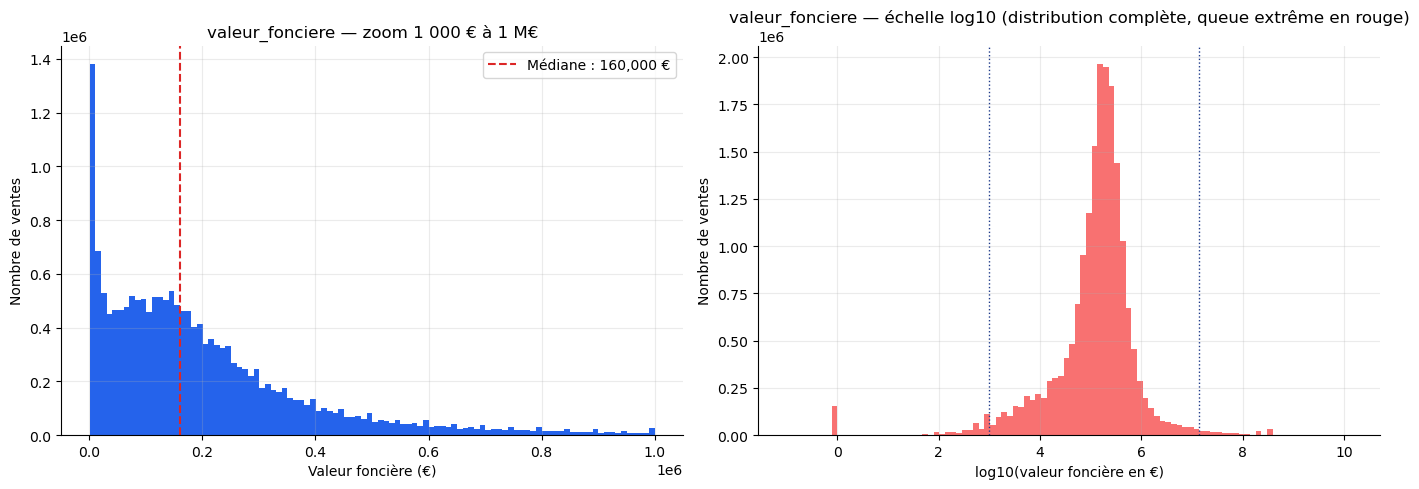

In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Zoom sur la plage typique du march\u00e9 r\u00e9sidentiel
vf_zoom = valeur_fonciere_ventes[(valeur_fonciere_ventes >= 1_000) & (valeur_fonciere_ventes <= 1_000_000)]
median_val = valeur_fonciere_ventes.median()

axes[0].hist(vf_zoom, bins=100, color=COLORS["bleu_primaire"], edgecolor="none")
axes[0].axvline(median_val, color=COLORS["rouge_exclusion"], linestyle="--",
                 label=f"M\u00e9diane : {median_val:,.0f} \u20ac")
axes[0].set_title("valeur_fonciere \u2014 zoom 1 000 \u20ac \u00e0 1 M\u20ac")
axes[0].set_xlabel("Valeur fonci\u00e8re (\u20ac)")
axes[0].set_ylabel("Nombre de ventes")
axes[0].legend()

# Vue compl\u00e8te en \u00e9chelle log10 pour visualiser la queue extr\u00eame
vf_positive = valeur_fonciere_ventes[valeur_fonciere_ventes > 0]
axes[1].hist(np.log10(vf_positive), bins=100, color=COLORS["rouge_modere"], edgecolor="none")
for p in (1_000, 13_650_000):
    axes[1].axvline(np.log10(p), color=COLORS["bleu_marine"], linestyle=":", linewidth=1)
axes[1].set_title("valeur_fonciere \u2014 \u00e9chelle log10 (distribution compl\u00e8te, queue extr\u00eame en rouge)")
axes[1].set_xlabel("log10(valeur fonci\u00e8re en \u20ac)")
axes[1].set_ylabel("Nombre de ventes")

plt.tight_layout()
plt.show()


- Médiane : 160 000€ (cohérent avec le marché français)
- Min : 0.10€, 1% : 100€ → cessions symboliques/donations, pas des transactions de marché
- 99% : 13.65M€, Max : 14.15Md€ → portefeuilles/erreurs, pas des biens individuels
- **Décision** : exclure valeur_fonciere < 1000€, traiter à part ou exclure > percentile 99

In [16]:
# Trouver des id_mutation avec à la fois Maison/Appartement ET Dépendance
sample = pd.read_csv(CSV_PATH, nrows=2_000_000, 
                      usecols=["id_mutation", "type_local", "valeur_fonciere", "surface_reelle_bati"])

# Compter combien de types différents par id_mutation
multi_type = sample.groupby("id_mutation")["type_local"].apply(lambda x: set(x.dropna()))
cas_mixtes = multi_type[multi_type.apply(lambda s: "Dépendance" in s and len(s) > 1)]

# Regarder quelques exemples concrets
exemples_ids = cas_mixtes.index[:5]
sample[sample["id_mutation"].isin(exemples_ids)].sort_values("id_mutation")

,id_mutation,valeur_fonciere,type_local,surface_reelle_bati
0,2021-1,185000.0,Dépendance,NaN
1,2021-1,185000.0,Maison,97.0
3203,2021-1000,72150.0,Dépendance,NaN
3204,2021-1000,72150.0,Appartement,86.0
280632,2021-100004,70000.0,Dépendance,NaN
280633,2021-100004,70000.0,Appartement,47.0
280650,2021-100008,161800.0,Maison,81.0
280651,2021-100008,161800.0,Dépendance,NaN
280674,2021-100017,320000.0,Maison,100.0
280675,2021-100017,320000.0,Dépendance,NaN


In [17]:
CHUNK_SIZE = 1_000_000
cols_needed = ["id_mutation", "type_local", "valeur_fonciere"]

summaries = []

for i, chunk in enumerate(pd.read_csv(CSV_PATH, usecols=cols_needed, chunksize=CHUNK_SIZE, low_memory=False)):
    g = chunk.groupby("id_mutation").agg(
        min_val=("valeur_fonciere", "min"),
        max_val=("valeur_fonciere", "max"),
        has_dependance=("type_local", lambda x: "Dépendance" in set(x.dropna())),
        has_main=("type_local", lambda x: bool(set(x.dropna()) & {"Maison", "Appartement"})),
    )
    summaries.append(g)
    print(f"Chunk {i+1} traité — {len(chunk):,} lignes")

print("Fusion des résumés...")
all_summary = pd.concat(summaries)

final = all_summary.groupby("id_mutation").agg(
    min_val=("min_val", "min"),
    max_val=("max_val", "max"),
    has_dependance=("has_dependance", "max"),
    has_main=("has_main", "max"),
)

final["valeur_coherente"] = final["min_val"] == final["max_val"]

Chunk 1 traité — 1,000,000 lignes
Chunk 2 traité — 1,000,000 lignes
Chunk 3 traité — 1,000,000 lignes
Chunk 4 traité — 1,000,000 lignes
Chunk 5 traité — 1,000,000 lignes
Chunk 6 traité — 1,000,000 lignes
Chunk 7 traité — 1,000,000 lignes
Chunk 8 traité — 1,000,000 lignes
Chunk 9 traité — 1,000,000 lignes
Chunk 10 traité — 1,000,000 lignes
Chunk 11 traité — 1,000,000 lignes
Chunk 12 traité — 1,000,000 lignes
Chunk 13 traité — 1,000,000 lignes
Chunk 14 traité — 1,000,000 lignes
Chunk 15 traité — 1,000,000 lignes
Chunk 16 traité — 1,000,000 lignes
Chunk 17 traité — 1,000,000 lignes
Chunk 18 traité — 1,000,000 lignes
Chunk 19 traité — 1,000,000 lignes
Chunk 20 traité — 1,000,000 lignes
Chunk 21 traité — 382,915 lignes
Fusion des résumés...


In [18]:
mixtes = final[final["has_dependance"] & final["has_main"]]
print(f"Transactions mixtes (Dépendance + Maison/Appartement) : {len(mixtes):,}")
print(mixtes["valeur_coherente"].value_counts())

Transactions mixtes (Dépendance + Maison/Appartement) : 2,661,868
valeur_coherente
True     2659866
False       2002
Name: count, dtype: int64


## 7. Répartition temporelle (nombre de ventes par mois)

Prépare l'angle storytelling : impact des taux d'intérêt 2022-2023 sur le volume de transactions.

In [19]:
monthly_counts = {}

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False,
                          usecols=["nature_mutation", "date_mutation"]):
    ventes = chunk[chunk["nature_mutation"] == "Vente"].copy()
    ventes["date_mutation"] = pd.to_datetime(ventes["date_mutation"], errors="coerce")
    ventes["year_month"] = ventes["date_mutation"].dt.to_period("M")
    counts = ventes["year_month"].value_counts()
    for period, count in counts.items():
        monthly_counts[period] = monthly_counts.get(period, 0) + count

monthly_series = pd.Series(monthly_counts).sort_index()
monthly_series

2021-01    262894
2021-02    259958
2021-03    335436
2021-04    319034
2021-05    328478
2021-06    437536
2021-07    498643
2021-08    300866
2021-09    406335
2021-10    378852
2021-11    327003
2021-12    467460
2022-01    303212
2022-02    314118
2022-03    381996
2022-04    342866
2022-05    355927
2022-06    415065
2022-07    423892
2022-08    288139
2022-09    392106
2022-10    337008
2022-11    315295
2022-12    451923
2023-01    276825
2023-02    270467
2023-03    333657
2023-04    267378
2023-05    285838
2023-06    350823
2023-07    334979
2023-08    229094
2023-09    300111
2023-10    297215
2023-11    256411
2023-12    363081
2024-01    221187
2024-02    233142
2024-03    254634
2024-04    256779
2024-05    243057
2024-06    284333
2024-07    341040
2024-08    208053
2024-09    287804
2024-10    297730
2024-11    253749
2024-12    377461
2025-01    239706
2025-02    241018
2025-03    302441
2025-04    300067
2025-05    229709
2025-06    312748
2025-07    365705
2025-08   

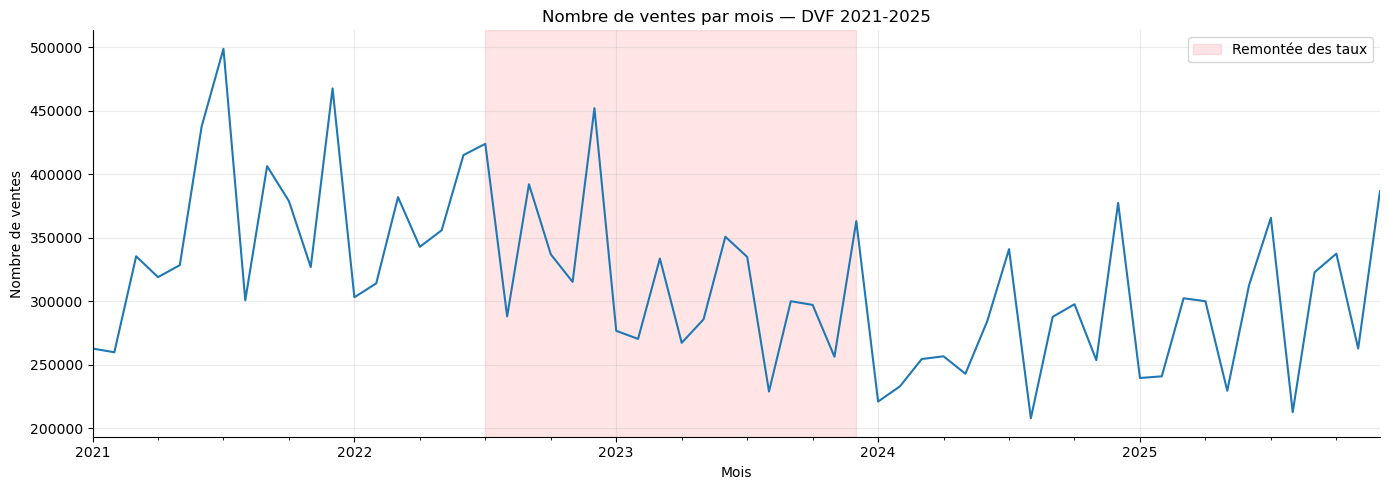

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
monthly_series.plot(ax=ax)
ax.set_title("Nombre de ventes par mois — DVF 2021-2025")
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de ventes")
ax.axvspan(pd.Period("2022-07"), pd.Period("2023-12"), color="red", alpha=0.1, label="Remontée des taux")
ax.legend()
plt.tight_layout()
plt.show()

### Volume mensuel — lecture du graphique

- **2021 - mi-2022** : marché actif, pics saisonniers élevés (jusqu'à ~499K ventes/mois
  en juillet 2021)
- **Mi-2022 à fin 2023 (remontée des taux)** : baisse structurelle nette — pics plus bas
  et creux nettement plus profonds (ex: 230K en août 2023 vs 300K en 2021)
- **2024-2025** : le marché ne retrouve jamais les niveaux d'avant-2022. Nouveaux
  planchers historiques atteints (208K en août 2024, 213K en août 2025) → impact
  durable, pas juste un ralentissement temporaire
- **Point d'attention** : la baisse semble amorcée légèrement avant le début de la
  zone surlignée → à confronter aux dates réelles des hausses de taux BCE (2022-2023)
  pour affiner la période de référence

---
**Note** : ce notebook couvre l'exploration initiale (aperçu, comptage, valeurs manquantes, répartitions,
distributions, tendance temporelle brute). Les vérifications approfondies et les règles de nettoyage
(vente en bloc, doublons, VEFA, géographie, surface/pièces, entonnoir) ont été déplacées dans
`02_regles_nettoyage_dvf.ipynb` pour garder ce notebook lisible et rapide à relancer.